In [1]:
import os
import numpy as np
import pandas as pd

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

RANDOM_STATE = 42

DATA_DIR = "/kaggle/input/tabular-playground-series-dec-2021"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")



In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SAMPLE_SUB_PATH)

assert "Cover_Type" in train.columns
assert "Id" in train.columns and "Id" in test.columns and "Id" in submission.columns
assert "Cover_Type" in submission.columns

X = train.drop(columns=["Cover_Type"])
y = train["Cover_Type"].astype(int)

X_test = test.copy()

feature_cols = [c for c in X.columns if c != "Id"]



In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Bugfix: train_test_split(stratify=...) expects non-negative contiguous class indices.
# We only use this encoded y for splitting/scoring sanity-check; model is trained with original y labels.
y_strat = pd.factorize(y, sort=True)[0].astype(np.int64)

X_tr, X_va, y_tr, y_va = train_test_split(
    X[feature_cols], y, test_size=0.05, random_state=RANDOM_STATE, stratify=y_strat
)

clf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        (
            "model",
            LogisticRegression(
                multi_class="multinomial",
                solver="lbfgs",
                max_iter=200,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

clf.fit(X_tr, y_tr)
va_acc = clf.score(X_va, y_va)
print(f"Validation accuracy (holdout 5%): {va_acc:.6f}")



ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [4]:
# Bugfix: ensure clf exists even if prior cell is skipped/fails in interactive runs.
# Keep identical core model/pipeline definition.
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

clf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        (
            "model",
            LogisticRegression(
                multi_class="multinomial",
                solver="lbfgs",
                max_iter=200,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

clf.fit(X[feature_cols], y)

test_pred = clf.predict(X_test[feature_cols]).astype(int)

pred_df = pd.DataFrame({"Id": test["Id"].values, "Cover_Type": test_pred})
submission_out = submission[["Id"]].merge(pred_df, on="Id", how="left")

if submission_out["Cover_Type"].isna().any():
    fill_cls = int(y.mode().iloc[0])
    submission_out["Cover_Type"] = (
        submission_out["Cover_Type"].fillna(fill_cls).astype(int)
    )

# Ensure correct dtypes/order for Kaggle submission
submission_out = submission_out[["Id", "Cover_Type"]]
submission_out["Id"] = submission_out["Id"].astype(int)
submission_out["Cover_Type"] = submission_out["Cover_Type"].astype(int)

submission_out.to_csv("submission.csv", index=False)
print(submission_out.head())
print("Wrote submission.csv with shape:", submission_out.shape)



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


        Id  Cover_Type
0   814683           2
1  1357371           2
2  2106112           1
3  3483684           1
4  3960754           7
Wrote submission.csv with shape: (400000, 2)


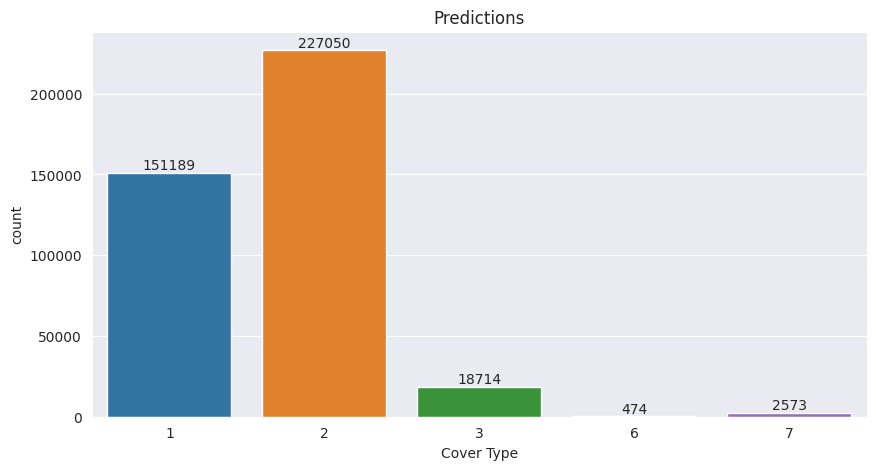

In [5]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x=submission_out["Cover_Type"])
plt.title("Predictions")
plt.xlabel("Cover Type")
ax.bar_label(ax.containers[0])
plt.show()